# **Visualize CASF-2016 Ki Dataset**

Visualization of data from CASF-2016 Ki dataset ([de Azevedo et al., 2024](https://pubmed.ncbi.nlm.nih.gov/38900052/)). Partially based on codes described in Géron, 2023 and Nield, 2022.

**References:**

de Azevedo WF Jr, Quiroga R, Villarreal MA, da Silveira NJF, Bitencourt-Ferreira G, da Silva AD, Veit-Acosta M, Oliveira PR, Tutone M, Biziukova N, Poroikov V, Tarasova O, Baud S. SAnDReS 2.0: Development of machine-learning models to explore the scoring function space. J Comput Chem. 2024 Oct 15;45(27):2333-2346. doi: 10.1002/jcc.27449. Epub 2024 Jun 20. PMID: 38900052.   [PubMed](https://pubmed.ncbi.nlm.nih.gov/38900052/)   

Géron, A. (2023). Hands-on machine learning with scikit-learn, keras and tensorflow: Concepts, tools, and techniques to build Intelligent Systems. O’Reilly Media, Inc.

Nield, T. (2022). Essential math for data science: Take Control of Your Data with Fundamental Linear Algebra, Probability, and Statistics. O’Reilly Media.

Code to visualize CASF-2016 Ki dataset follows.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1146 entries, 0 to 1145
Data columns (total 31 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   PDB                               1146 non-null   object 
 1   Ligand                            1146 non-null   object 
 2   Chain                             1146 non-null   object 
 3   Number                            1146 non-null   int64  
 4   Resolution(A)                     1146 non-null   float64
 5   Ligand Occupation Factor          1146 non-null   float64
 6   Ki(M)                             1146 non-null   float64
 7   log(Ki)                           1146 non-null   float64
 8   pKi                               1146 non-null   float64
 9   RMSD(A)                           1146 non-null   object 
 10  Torsions                          1146 non-null   int64  
 11  Q                                 1146 non-null   float64
 12  Averag

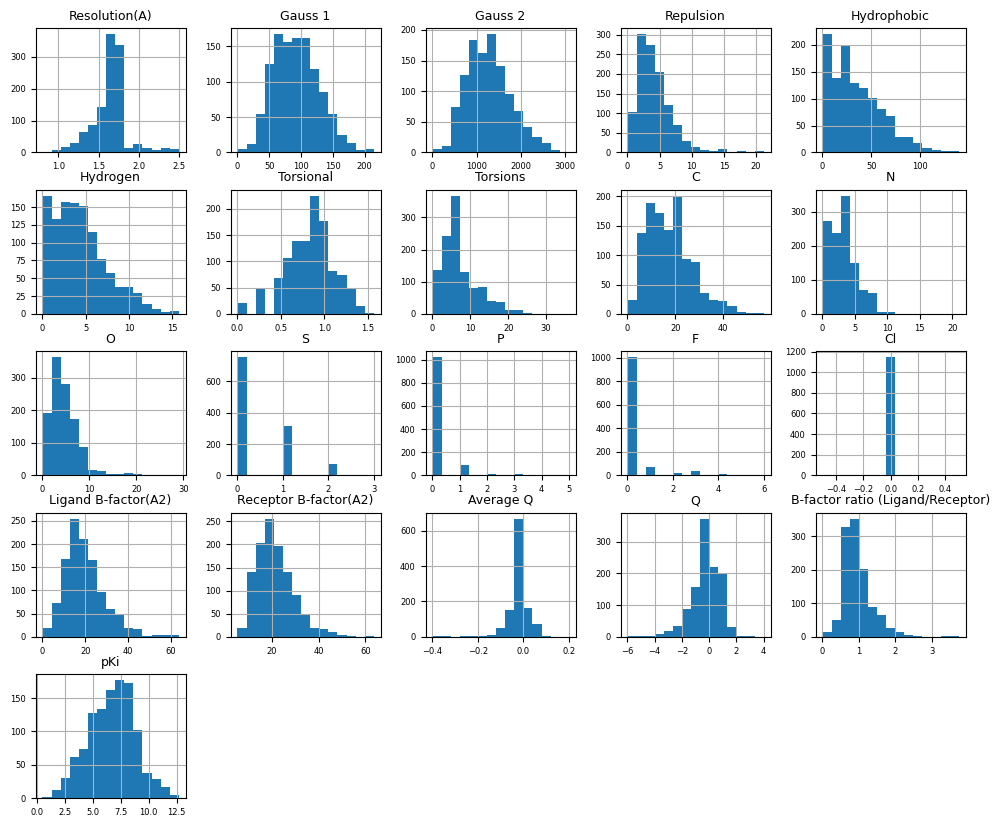


Histogram saved in the file: histogram_CASF-2016_Ki.png

Correlation matrix data saved in the file: scatter_matrix.csv


<Figure size 640x480 with 0 Axes>

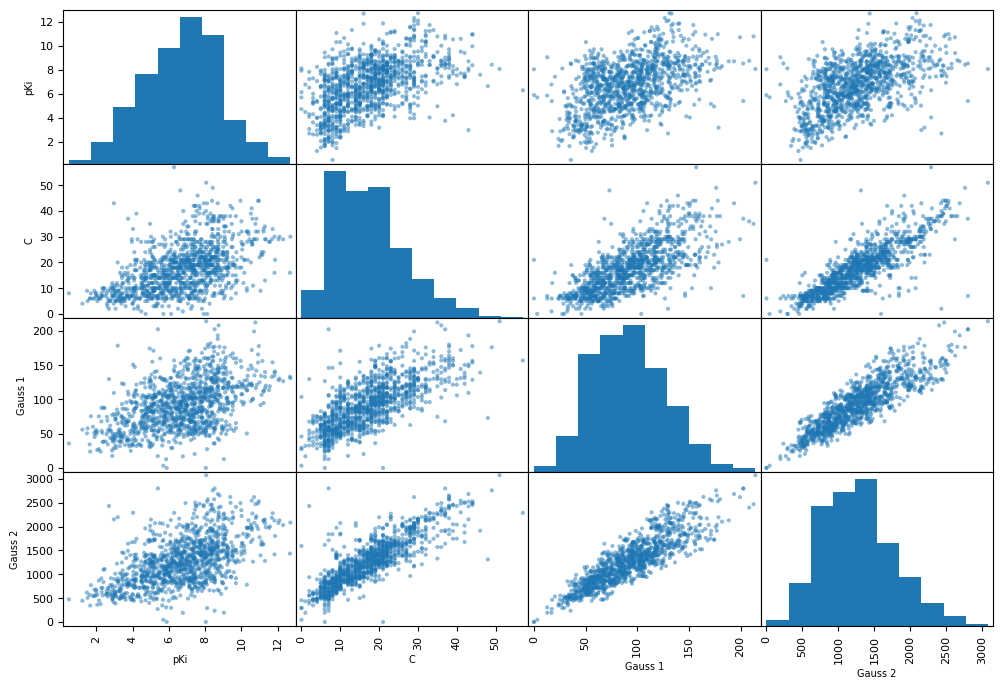


Correlation matrix plot saved in the file: scatter_matrix_plot.png


<Figure size 640x480 with 0 Axes>

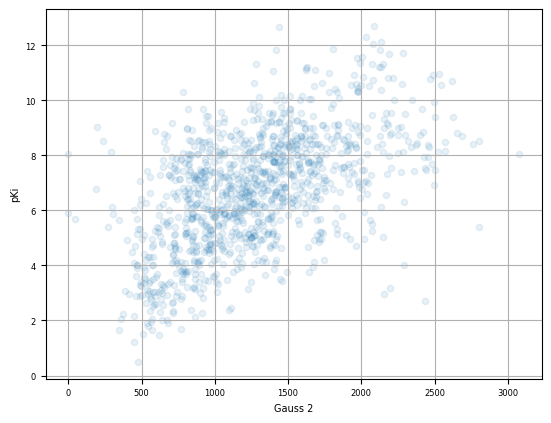


Scatter plot for Gauss 2 vs pKi saved in the file:Gauss 2_vs_pKi_scatterplot.png


<Figure size 640x480 with 0 Axes>

In [ ]:
#!/usr/bin/env python3
#
################################################################################
# Dr. Walter F. de Azevedo, Jr.                                                #
# https://github.com/azevedolab                                                #
# July 20, 2024                                                                #
################################################################################
#
# Import section
import urllib.request
import pandas as pd
from matplotlib import pyplot as plt
from pandas.plotting import scatter_matrix

################################################################################
# CASF-2016 Ki (Full Dataset)                                                  #
################################################################################
# Download and read a csv file
file_in = "CASF-2016_Ki.csv"
print("Downloading file: "+file_in,end="...")
df = pd.read_csv('https://drive.usercontent.google.com/u/0/uc?id=1JRcUBVjV99E8jAjvEOdilCl4nXS6sNIg&export=download', delimiter=",")
#df = pd.read_csv("https://bit.ly/CASF-2016_Ki_data",delimiter=",")
print("done!")

feature_target_list = ["Gauss 1","Gauss 2","Repulsion","Hydrophobic","Hydrogen",
"Torsional","Torsions","C","N","O","S","P","Receptor B-factor(A2)","Average Q",
"Q","B-factor ratio (Ligand/Receptor)","pKi"]
extended_feature_target_list = ["Resolution(A)","Gauss 1","Gauss 2","Repulsion",
"Hydrophobic","Hydrogen","Torsional","Torsions","C","N","O","S","P","F","Cl",
"Ligand B-factor(A2)","Receptor B-factor(A2)","Average Q","Q",
"B-factor ratio (Ligand/Receptor)","pKi"]
df_extended =  df[extended_feature_target_list]
df_feature_target =  df[feature_target_list]

# To get rid of indexes in a dateframe
#df_target = df["pKi"]
#df_target = df_target.values[:]

# Show some information regading the data
data_info = df.info()

# Generate histogram
plt.rc('font', size=9)
plt.rc('axes', labelsize=7, titlesize=9)
plt.rc('legend', fontsize=9)
plt.rc('xtick', labelsize=6)
plt.rc('ytick', labelsize=6)
df_extended.hist(bins=15, figsize=(12, 10))
plt.show()
plt.savefig("histogram_CASF-2016_Ki.png",dpi=600)
print("\nHistogram saved in the file: histogram_CASF-2016_Ki.png")

# Looking for Correlations
corr_matrix = df_feature_target.corr(numeric_only=True)
corr_matrix["pKi"].sort_values(ascending=False)
corr_matrix.to_csv("scatter_matrix.csv", sep=',', index=False, encoding='utf-8')
print("\nCorrelation matrix data saved in the file: scatter_matrix.csv")
attributes = ["pKi", "C", "Gauss 1","Gauss 2"]
scatter_matrix(df_feature_target[attributes], figsize=(12, 8))
plt.show()
plt.savefig("scatter_matrix_plot.png",dpi=600)
print("\nCorrelation matrix plot saved in the file: scatter_matrix_plot.png")
df.plot(kind="scatter", x="Gauss 2", y="pKi",
             alpha=0.1, grid=True)
plt.show()
plt.savefig("Gauss 2_vs_pKi_scatterplot.png",dpi=600)
msg_out = "\nScatter plot for Gauss 2 vs pKi saved in the file:"
msg_out += "Gauss 2_vs_pKi_scatterplot.png"
print(msg_out)